## Exploratory Data Analysis

### Importing and checking data quality

In [4]:
#Importing relevant libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [5]:
#Loading the dataset

df = pd.read_csv('housing.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.shape

(20640, 10)

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
#Checking for missing values

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Handling Missing Values

There were two options in cleaning these missing values. I could either drop the rows with the missing values or fill them. I chose to fill them in order to retain relevant training data. Also, I filled with the median and not the mean to avoid the sensitivities and outlier effect that may result from filling with the mean.

In [10]:
#Filling missing columns with median 

df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace = True)

#Confirming that missing values are handled
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## Some visual analysis

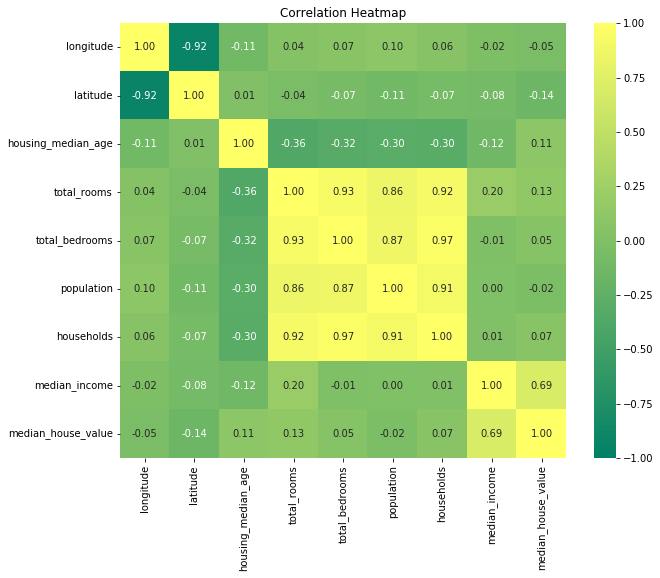

In [11]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.select_dtypes(include = 'number').corr(), annot = True, fmt = '.2f', cmap = 'summer', vmin = -1, vmax = 1)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap reveals that the highest correlation with the target (median_house_value) is median_income. There seems to be a weaker correlation to the rest of the numerical features.

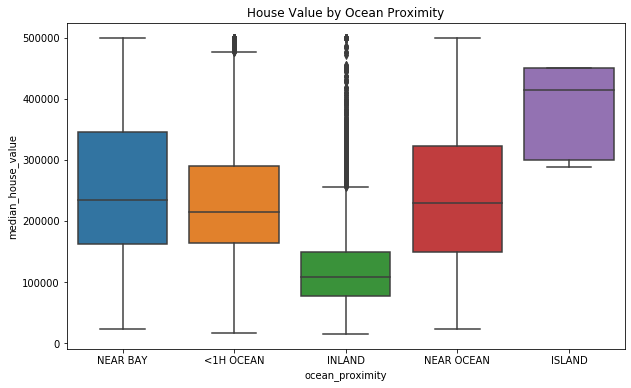

In [12]:
plt.figure(figsize = (10,6))
sns.boxplot(x = 'ocean_proximity', y = 'median_house_value', data = df)
plt.title('House Value by Ocean Proximity')
plt.show()

Ocean Proximity signals clearly as a valuable predictive feature as it shows distinct patterns in relation to house values. 

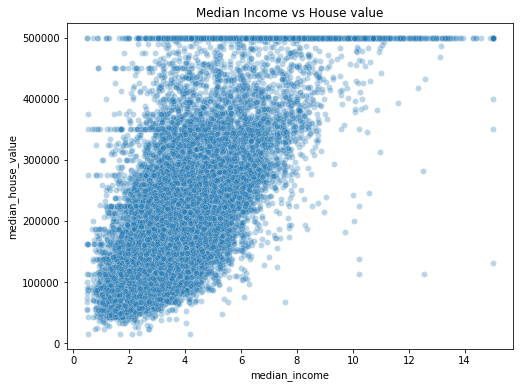

In [13]:
plt.figure(figsize = (8, 6))
sns.scatterplot (x = 'median_income', y = 'median_house_value', data = df, alpha = 0.3)
plt.title('Median Income vs House value')
plt.show()

The scatterplot(median value against median income) confirms median_income as the strongest predictor as it clearly displays a strong positive relationship. The relationship appears to be non-linear, variance increasing with income levels and an artificial cap at $500,000.

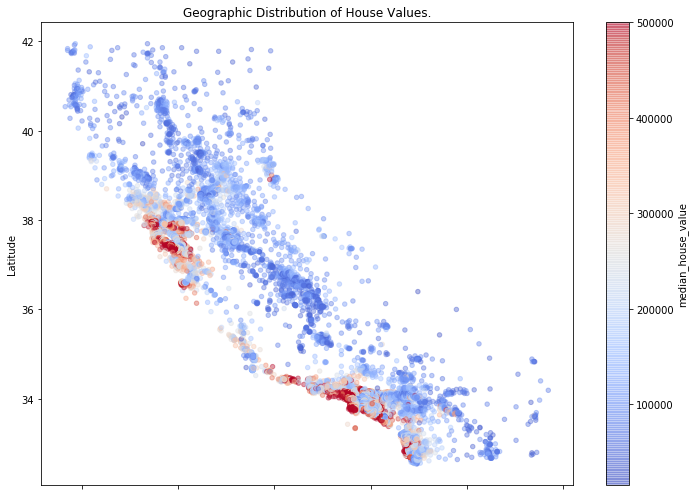

In [14]:
df.plot(kind = 'scatter', x = 'longitude', y = 'latitude', c = 'median_house_value', cmap = 'coolwarm', figsize = (10, 7), colorbar = True, alpha = 0.4)
plt.title('Geographic Distribution of House Values.')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


Geographical coordinates (longitude and latitude) showed low correlations to the target as individual features(-0.05 and -014) but together, they clearly show a pattern, revealing a cluster of high-value houses at the coastlines, with inland houses showing significantly lower house values. This demonstrates that correlation coefficient alone is not enough to determine the relevance of a feature in training the model. 

In [15]:
df_encoded =  pd.get_dummies(df, columns = ['ocean_proximity'], drop_first = True)

df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [16]:
df_encoded.shape

(20640, 13)

In [17]:
#Exporting cleaned data set for safe keeping

df_encoded.to_csv('cleaned_housing.csv', index = False)

## Feature Selection, Modeling and Prediction

In [18]:
#Seperating features from target

X = df_encoded.drop('median_house_value', axis = 1)
y = df_encoded['median_house_value']

In [19]:
y.max()
y.value_counts().head()

500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
Name: median_house_value, dtype: int64

Limitation: 4.7% of target values (965 rows) are capped at $500,001, the maximum value in the dataset. This is likely to affect training causing the model to underpredict prices for house values and hence inflating RMSE at the upper bounds.

In [20]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 12), (4128, 12), (16512,), (4128,))

In [21]:
 X.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [22]:
#Creating standard scaler instance. Scaling is necessary to resolve the value distance between columns with values spanning hundreds of thousands to those hosting single units

numeric_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

sc = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = sc.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = sc.transform(X_test[numeric_cols])

In [23]:
print(X_train_scaled[numeric_cols].describe())

print(X_test_scaled[['ocean_proximity_INLAND']].describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  1.651200e+04  1.651200e+04        1.651200e+04  1.651200e+04   
mean   1.769754e-15  1.781790e-17       -9.136210e-17  1.422742e-17   
std    1.000030e+00  1.000030e+00        1.000030e+00  1.000030e+00   
min   -2.377207e+00 -1.447697e+00       -2.190766e+00 -1.214029e+00   
25%   -1.110749e+00 -8.018107e-01       -8.417859e-01 -5.463144e-01   
50%    5.346501e-01 -6.473597e-01        3.108328e-02 -2.359097e-01   
75%    7.839530e-01  9.720351e-01        6.658972e-01  2.382046e-01   
max    2.628794e+00  2.951816e+00        1.856173e+00  1.686670e+01   

       total_bedrooms    population    households  median_income  
count    1.651200e+04  1.651200e+04  1.651200e+04   1.651200e+04  
mean    -6.230212e-17  2.397684e-17 -3.663091e-17  -6.815177e-17  
std      1.000030e+00  1.000030e+00  1.000030e+00   1.000030e+00  
min     -1.282826e+00 -1.251913e+00 -1.309827e+00  -1.775438e+00  
25%     -5.769692e-01 -5.

In [24]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [25]:
y_pred = model.predict(X_test_scaled)

In [26]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
20046,47700.0,54055.448899
3024,45800.0,124225.338937
15663,500001.0,255489.379492
20484,218600.0,268002.431569
9814,278000.0,262769.434816
13311,158700.0,139606.303956
7113,198200.0,290665.423914
7668,157500.0,228264.876375
18246,340000.0,256506.785610
5723,446600.0,407923.858435


The table above shows there was a massive underprediction at the cap value. This is evidence that the model's prediction ability is impacted negatively by the artificial cap. 

In [27]:
#Root mean square evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

70060.52184473521


RMSE = 70060.52

This is a poor score. It is a 33.9% error compared to the mean of the actual target values. I believe that one reason for the large error may be traced back to the artificial cap noted and predicted earlier.

In [28]:
(y.mean(), y.median(), y.std())

(206855.81690891474, 179700.0, 115395.6158744132)

In [29]:
#Confirming the cap effect hypothesis by running rmse without the capped values.

mask = y_test < 500001
rsme_uncapped = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
print(rsme_uncapped)
print("Capped rows dropped:", (len(y_test) - mask.sum()) )

62223.16071809816
Capped rows dropped: 179


The above result shows that the cap rows make up about 4.3% of the total test rows and accounts for about 11% of the RMSE, hence the drop.

However the RMSE is still shows a poor performance. Another hypothesis to test is that the model is too simple for the problem and so needs a more non-linear model.

In [30]:
coefficients = pd.DataFrame({'Feature':X_train_scaled.columns, 'Coefficient': model.coef_})

coefficients ['AbsCoefficient'] = coefficients ['Coefficient'].abs()

print(coefficients.sort_values(by = 'AbsCoefficient', ascending = False))

                       Feature    Coefficient  AbsCoefficient
9       ocean_proximity_ISLAND  136125.072615   136125.072615
7                median_income   75167.774766    75167.774766
1                     latitude  -54415.696144    54415.696144
0                    longitude  -53826.648016    53826.648016
5                   population  -43403.432427    43403.432427
4               total_bedrooms   43068.181842    43068.181842
8       ocean_proximity_INLAND  -39786.656161    39786.656161
6                   households   18382.196324    18382.196324
2           housing_median_age   13889.866189    13889.866189
3                  total_rooms  -13094.251162    13094.251162
10    ocean_proximity_NEAR BAY   -5136.642217     5136.642217
11  ocean_proximity_NEAR OCEAN    3431.140073     3431.140073


In [31]:
X_train['ocean_proximity_ISLAND'].sum()

4

In [32]:
X_train['ocean_proximity_NEAR BAY'].sum()

1854

In [33]:
X_train['total_rooms'].sum()

43624783.0

In [34]:
X_train['ocean_proximity_INLAND'].sum()

5227

In [35]:
X_train['ocean_proximity_NEAR OCEAN'].sum()

2086